# MDI3003 Advanced Predictive Analytics — Experiment 08
## Track B: Crop Label Classification Extension (D3 Dataset)
**Course:** MDI3003 Advanced Predictive Analytics  
**Experiment:** 08 — Guided Crop-Label Classification Extension  
**Target:** Multi-class Crop Category (22 distinct crop labels)  
**Workflow:** End-to-end Executed Machine Learning Pipeline


In [1]:
import sys
from pathlib import Path
# Ensure project root is on sys.path for robust module resolution
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Enable inline plotting in Jupyter environments
%matplotlib inline


## 1. Objective and Scope
This independent extension evaluates supervised classification for predicting 22 crop labels from 7 continuous soil and environmental features ($N, P, K$, temperature, humidity, pH, rainfall).

> **Agronomic Caution:** This task predicts *curated dataset labels* from synthetic/augmented agro-climatic profiles. It does NOT establish an agronomically safe, economically optimal, or farmer-approved crop selection advice.

## 2. Dataset Loading and Inspection
Loading the canonical D3 Crop Recommendation dataset and inspecting feature columns and dimensions.

In [2]:
import pandas as pd
from src.config import CROP_LABELS_CANONICAL_FILE, CLS_FEATURES, CLS_TARGET

df_cls = pd.read_csv(CROP_LABELS_CANONICAL_FILE)
print(f'Loaded Canonical D3 Dataset: {df_cls.shape[0]:,} rows, {df_cls.shape[1]} columns')
print(f'Predictor Features ({len(CLS_FEATURES)}): {list(CLS_FEATURES)}')
print(f'Target Column: {CLS_TARGET} ({df_cls[CLS_TARGET].nunique()} distinct classes)')
display(df_cls.head())


Loaded Canonical D3 Dataset: 2,200 rows, 9 columns
Predictor Features (7): ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Target Column: label (22 distinct classes)


,row_id,N,P,K,temperature,humidity,ph,rainfall,label
0,CROP_000001,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,CROP_000002,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,CROP_000003,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,CROP_000004,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,CROP_000005,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 3. Data Quality and Validation
Automated data validation checks value ranges, absence of missing values, and schema integrity.

In [3]:
from src.validate_data import validate_classification_data

cls_val_report = validate_classification_data(CROP_LABELS_CANONICAL_FILE)
print('Classification Validation Status:', cls_val_report['status'])
print(f'Total Validated Rows: {cls_val_report["total_rows"]:,}')
print(f'Class Balance: {cls_val_report["num_classes"]} classes, minimum {cls_val_report["min_class_count"]} records each')


[2026-09-12 02:34:10] [INFO] [validate_data]: Validating classification dataset: .\data\processed\crop_labels_canonical.csv


[2026-09-12 02:34:10] [INFO] [validate_data]: Classification validation PASSED. Report saved to .\artifacts\data_validation\classification_validation.json


Classification Validation Status: PASSED
Total Validated Rows: 2,200
Class Balance: 22 classes, minimum 100 records each


## 4. Explicit Independence (IID) Justification Review
Before performing random stratified splitting, the project mandates an explicit independence audit. Because D3 is a curated tabular benchmark without temporal timestamps or geographic cluster IDs, a stratified holdout split is operationally justified for comparative modeling.

> **Audit Qualification:** Exact statistical independence is not empirically established across all potential covariates, as D3 observations derive from synthetic augmentation. The evaluation reflects benchmark screening performance.

In [4]:
from src.config import IID_JUSTIFICATION_NOTE
print('Formal IID Justification Note:')
print(IID_JUSTIFICATION_NOTE)


Formal IID Justification Note:
Supplied D3 dataset consists of synthetic/augmented tabular observations (100 balanced samples per class across 22 classes) without temporal stamps or grouped farm/field IDs. When iid_justified is set to true, a reproducible stratified holdout split is executed.


## 5. Stratified Holdout Partitioning
The canonical dataset is partitioned into 60% training, 20% validation, and 20% test splits using stratified sampling.

In [5]:
from src.split_data import get_classification_splits

df_cls_split = get_classification_splits(df_cls, iid_justified=True, save_manifest=False)
train_cls = df_cls_split[df_cls_split['split'] == 'train'].copy()
val_cls = df_cls_split[df_cls_split['split'] == 'validation'].copy()
test_cls = df_cls_split[df_cls_split['split'] == 'test'].copy()

print('Split Execution Completed.')


[2026-09-12 02:34:14] [INFO] [split_data]: IID assumption explicitly justified. Proceeding with stratified 60/20/20 split.


Split Execution Completed.


## 6. Split Counts and Class Balance Verification
Verifying observation counts and stratified balance across all 22 classes.

In [6]:
counts = df_cls_split['split'].value_counts().loc[['train', 'validation', 'test']]
shares = (counts / len(df_cls_split)).map('{:.1%}'.format)
split_df = pd.DataFrame({'Count': counts, 'Share': shares})
display(split_df)

# Verify equal class representation in each split
print('Per-class count in train:', train_cls[CLS_TARGET].value_counts().unique())
print('Per-class count in validation:', val_cls[CLS_TARGET].value_counts().unique())
print('Per-class count in test:', test_cls[CLS_TARGET].value_counts().unique())


,Count,Share
split,,
train,1320,60.0%
validation,440,20.0%
test,440,20.0%


Per-class count in train: [60]
Per-class count in validation: [20]
Per-class count in test: [20]


## 7. Preprocessing Pipeline Architecture
All 7 numeric features are normalized using median imputation followed by standard scaling within a scikit-learn Pipeline.

In [7]:
from src.preprocessing import build_classification_preprocessor

cls_preprocessor = build_classification_preprocessor()
display(cls_preprocessor)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

## 8. Candidate Models Initialization
Three candidate architectures are evaluated:
1. **Majority Baseline (`DummyClassifier`):** Predicts the most frequent training class.
2. **Multinomial Logistic Regression (`LogisticRegression`):** Linear decision boundaries with L2 regularization.
3. **Random Forest Classifier (`RandomForestClassifier`):** Non-linear ensemble (60 estimators, `min_samples_leaf=2`).

In [8]:
from src.models import get_classification_models

cls_candidates = get_classification_models()
for name, pipe in cls_candidates.items():
    print(f'- {name:<10}: {pipe.named_steps["model"]}')


- majority  : DummyClassifier(strategy='most_frequent')
- logistic  : LogisticRegression(max_iter=2000, random_state=42)
- forest    : RandomForestClassifier(min_samples_leaf=2, n_estimators=60, n_jobs=2,
                       random_state=42)


## 9. Model Fitting and Validation Evaluation
Fitting each candidate strictly on the training partition and evaluating macro F1 on the untouched validation holdout.

In [9]:
import time
from src.evaluation import evaluate_classification

val_records = []
fitted_candidates = {}

for name, pipe in cls_candidates.items():
    t0 = time.perf_counter()
    pipe.fit(train_cls[CLS_FEATURES], train_cls[CLS_TARGET])
    fit_time = time.perf_counter() - t0
    fitted_candidates[name] = pipe
    
    val_pred = pipe.predict(val_cls[CLS_FEATURES])
    metrics = evaluate_classification(val_cls[CLS_TARGET], val_pred)
    val_records.append({
        'model': name,
        'fit_seconds': round(fit_time, 3),
        'macro_F1': metrics['macro_F1'],
        'accuracy': metrics['accuracy'],
        'macro_precision': metrics['macro_precision'],
        'macro_recall': metrics['macro_recall'],
    })

val_results_df = pd.DataFrame(val_records).sort_values('macro_F1', ascending=False).reset_index(drop=True)
display(val_results_df)


,model,fit_seconds,macro_F1,accuracy,macro_precision,macro_recall
0,forest,0.486,0.9932,0.9932,0.9933,0.9932
1,logistic,0.161,0.9726,0.9727,0.9730,0.9727
2,majority,0.018,0.0040,0.0455,0.0021,0.0455


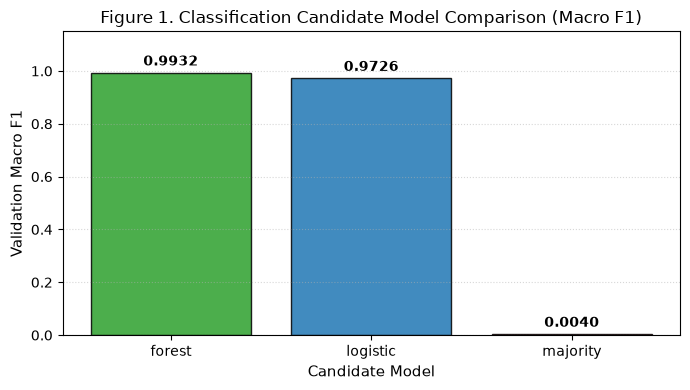

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
bars = plt.bar(val_results_df['model'], val_results_df['macro_F1'], color=['#2ca02c', '#1f77b4', '#d62728'], edgecolor='black', alpha=0.85)
plt.title('Figure 1. Classification Candidate Model Comparison (Macro F1)', fontsize=12)
plt.xlabel('Candidate Model', fontsize=11)
plt.ylabel('Validation Macro F1', fontsize=11)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.015, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 1.15)
plt.grid(True, linestyle=':', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()


**Figure 1. Classification Candidate Model Comparison (Macro F1):**  
Random Forest achieves the highest validation macro F1, followed by Logistic Regression, while the Majority baseline performs near zero. Non-linear ensemble decision boundaries effectively partition the multi-dimensional soil and environmental feature space.

## 10. Candidate Selection Rationale
The model with the highest validation macro F1 is selected for hyperparameter tuning.

In [11]:
selected_candidate = val_results_df.iloc[0]['model']
print(f'Selected Best Candidate Architecture: {selected_candidate}')
print(f'Validation Macro F1: {val_results_df.iloc[0]["macro_F1"]:.4f}')


Selected Best Candidate Architecture: forest
Validation Macro F1: 0.9932


## 11. Hyperparameter Tuning on Training Data Only
Tuning is performed strictly on training data using 3-fold Stratified Cross-Validation via `GridSearchCV`.

In [12]:
import joblib
from src.tuning import tune_classification_model
from src.config import TUNING_DIR, MODELS_CLS_DIR, get_current_config_sha256
from src.utils import compute_sha256, load_json

data_sha = compute_sha256(CROP_LABELS_CANONICAL_FILE)
cfg_sha = get_current_config_sha256()
cls_best_file = TUNING_DIR / 'classification_best_params.json'
cls_tuned_file = MODELS_CLS_DIR / 'tuned_selected_model.joblib'

if cls_best_file.exists() and cls_tuned_file.exists():
    print('Loading verified development tuning artifacts:')
    tuning_meta = load_json(cls_best_file)
    tuned_pipe = joblib.load(cls_tuned_file)
else:
    tuned_pipe, tuning_meta = tune_classification_model(
        selected_model_name=selected_candidate,
        base_pipeline=fitted_candidates[selected_candidate],
        df_train=train_cls,
        df_val=val_cls,
        data_sha256=data_sha,
        config_sha256=cfg_sha,
    )
print('Best CV Parameters:', tuning_meta.get('best_params'))
print(f'Best CV Macro F1: {tuning_meta.get("best_cv_macro_f1"):.4f}')


Loading verified development tuning artifacts:
Best CV Parameters: {'model__max_depth': 8, 'model__min_samples_leaf': 2, 'model__n_estimators': 60}
Best CV Macro F1: 0.9939


## 12. Tuned vs Default Model Comparison on Validation Holdout
Evaluating whether the tuned model improves validation macro F1 over the default configuration. Test data remains untouched during this decision.

In [13]:
val_pred_default = fitted_candidates[selected_candidate].predict(val_cls[CLS_FEATURES])
m_default = evaluate_classification(val_cls[CLS_TARGET], val_pred_default)

val_pred_tuned = tuned_pipe.predict(val_cls[CLS_FEATURES])
m_tuned = evaluate_classification(val_cls[CLS_TARGET], val_pred_tuned)

comparison_df = pd.DataFrame([
    {'Configuration': f'Default {selected_candidate}', 'Validation Macro F1': m_default['macro_F1'], 'Validation Accuracy': m_default['accuracy']},
    {'Configuration': f'Tuned {selected_model_name if "selected_model_name" in locals() else selected_candidate}', 'Validation Macro F1': m_tuned['macro_F1'], 'Validation Accuracy': m_tuned['accuracy']},
])
display(comparison_df)

use_tuned = (m_tuned['macro_F1'] >= m_default['macro_F1'])
if use_tuned:
    final_cls_pipe = tuned_pipe
    final_cls_name = f'{selected_candidate}_tuned'
else:
    final_cls_pipe = fitted_candidates[selected_candidate]
    final_cls_name = selected_candidate

print(f'Default {selected_candidate} validation macro F1: {m_default["macro_F1"]:.4f}')
print(f'Tuned {selected_candidate} validation macro F1: {m_tuned["macro_F1"]:.4f}')
print(f'Final selection: {final_cls_name}')
print('Selection reason: validation-only comparison')


,Configuration,Validation Macro F1,Validation Accuracy
0,Default forest,0.9932,0.9932
1,Tuned forest,0.9863,0.9864


Default forest validation macro F1: 0.9932
Tuned forest validation macro F1: 0.9863
Final selection: forest
Selection reason: validation-only comparison


## 13. Final Classification Selection Commitment
Committing the selected classification model architecture based strictly on development evidence.

In [14]:
print(f'Committed Final Classification Model: {final_cls_name}')
print(f'Used Hyperparameter Tuning: {use_tuned}')


Committed Final Classification Model: forest
Used Hyperparameter Tuning: False


## 14. Locked Test Set Evaluation
Evaluating the final selected model and majority baseline on the locked test partition (440 samples).

In [15]:
test_pred_final = final_cls_pipe.predict(test_cls[CLS_FEATURES])
test_metrics_final = evaluate_classification(test_cls[CLS_TARGET], test_pred_final)

majority_pipe = fitted_candidates['majority']
test_pred_maj = majority_pipe.predict(test_cls[CLS_FEATURES])
test_metrics_maj = evaluate_classification(test_cls[CLS_TARGET], test_pred_maj)

test_results_summary = pd.DataFrame([
    {'model': final_cls_name, 'macro_F1': test_metrics_final['macro_F1'], 'accuracy': test_metrics_final['accuracy'], 'macro_precision': test_metrics_final['macro_precision'], 'macro_recall': test_metrics_final['macro_recall']},
    {'model': 'majority', 'macro_F1': test_metrics_maj['macro_F1'], 'accuracy': test_metrics_maj['accuracy'], 'macro_precision': test_metrics_maj['macro_precision'], 'macro_recall': test_metrics_maj['macro_recall']},
])
display(test_results_summary)


,model,macro_F1,accuracy,macro_precision,macro_recall
0,forest,0.9909,0.9909,0.9919,0.9909
1,majority,0.0040,0.0455,0.0021,0.0455


## 15. Per-Class Performance Metrics Breakdown
Detailed precision, recall, and F1-score across each of the 22 individual crop categories.

In [16]:
from sklearn.metrics import classification_report

report_dict = classification_report(test_cls[CLS_TARGET], test_pred_final, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
display(report_df.head(15))


,precision,recall,f1-score,support
apple,1.000000,1.00,1.000000,20.0
banana,1.000000,1.00,1.000000,20.0
blackgram,1.000000,1.00,1.000000,20.0
chickpea,1.000000,1.00,1.000000,20.0
coconut,1.000000,1.00,1.000000,20.0
coffee,1.000000,1.00,1.000000,20.0
cotton,1.000000,1.00,1.000000,20.0
grapes,1.000000,1.00,1.000000,20.0
jute,0.869565,1.00,0.930233,20.0
kidneybeans,1.000000,1.00,1.000000,20.0


## 16. Multiclass Confusion Matrix Display
Visualizing actual vs predicted crop labels on the locked test partition.

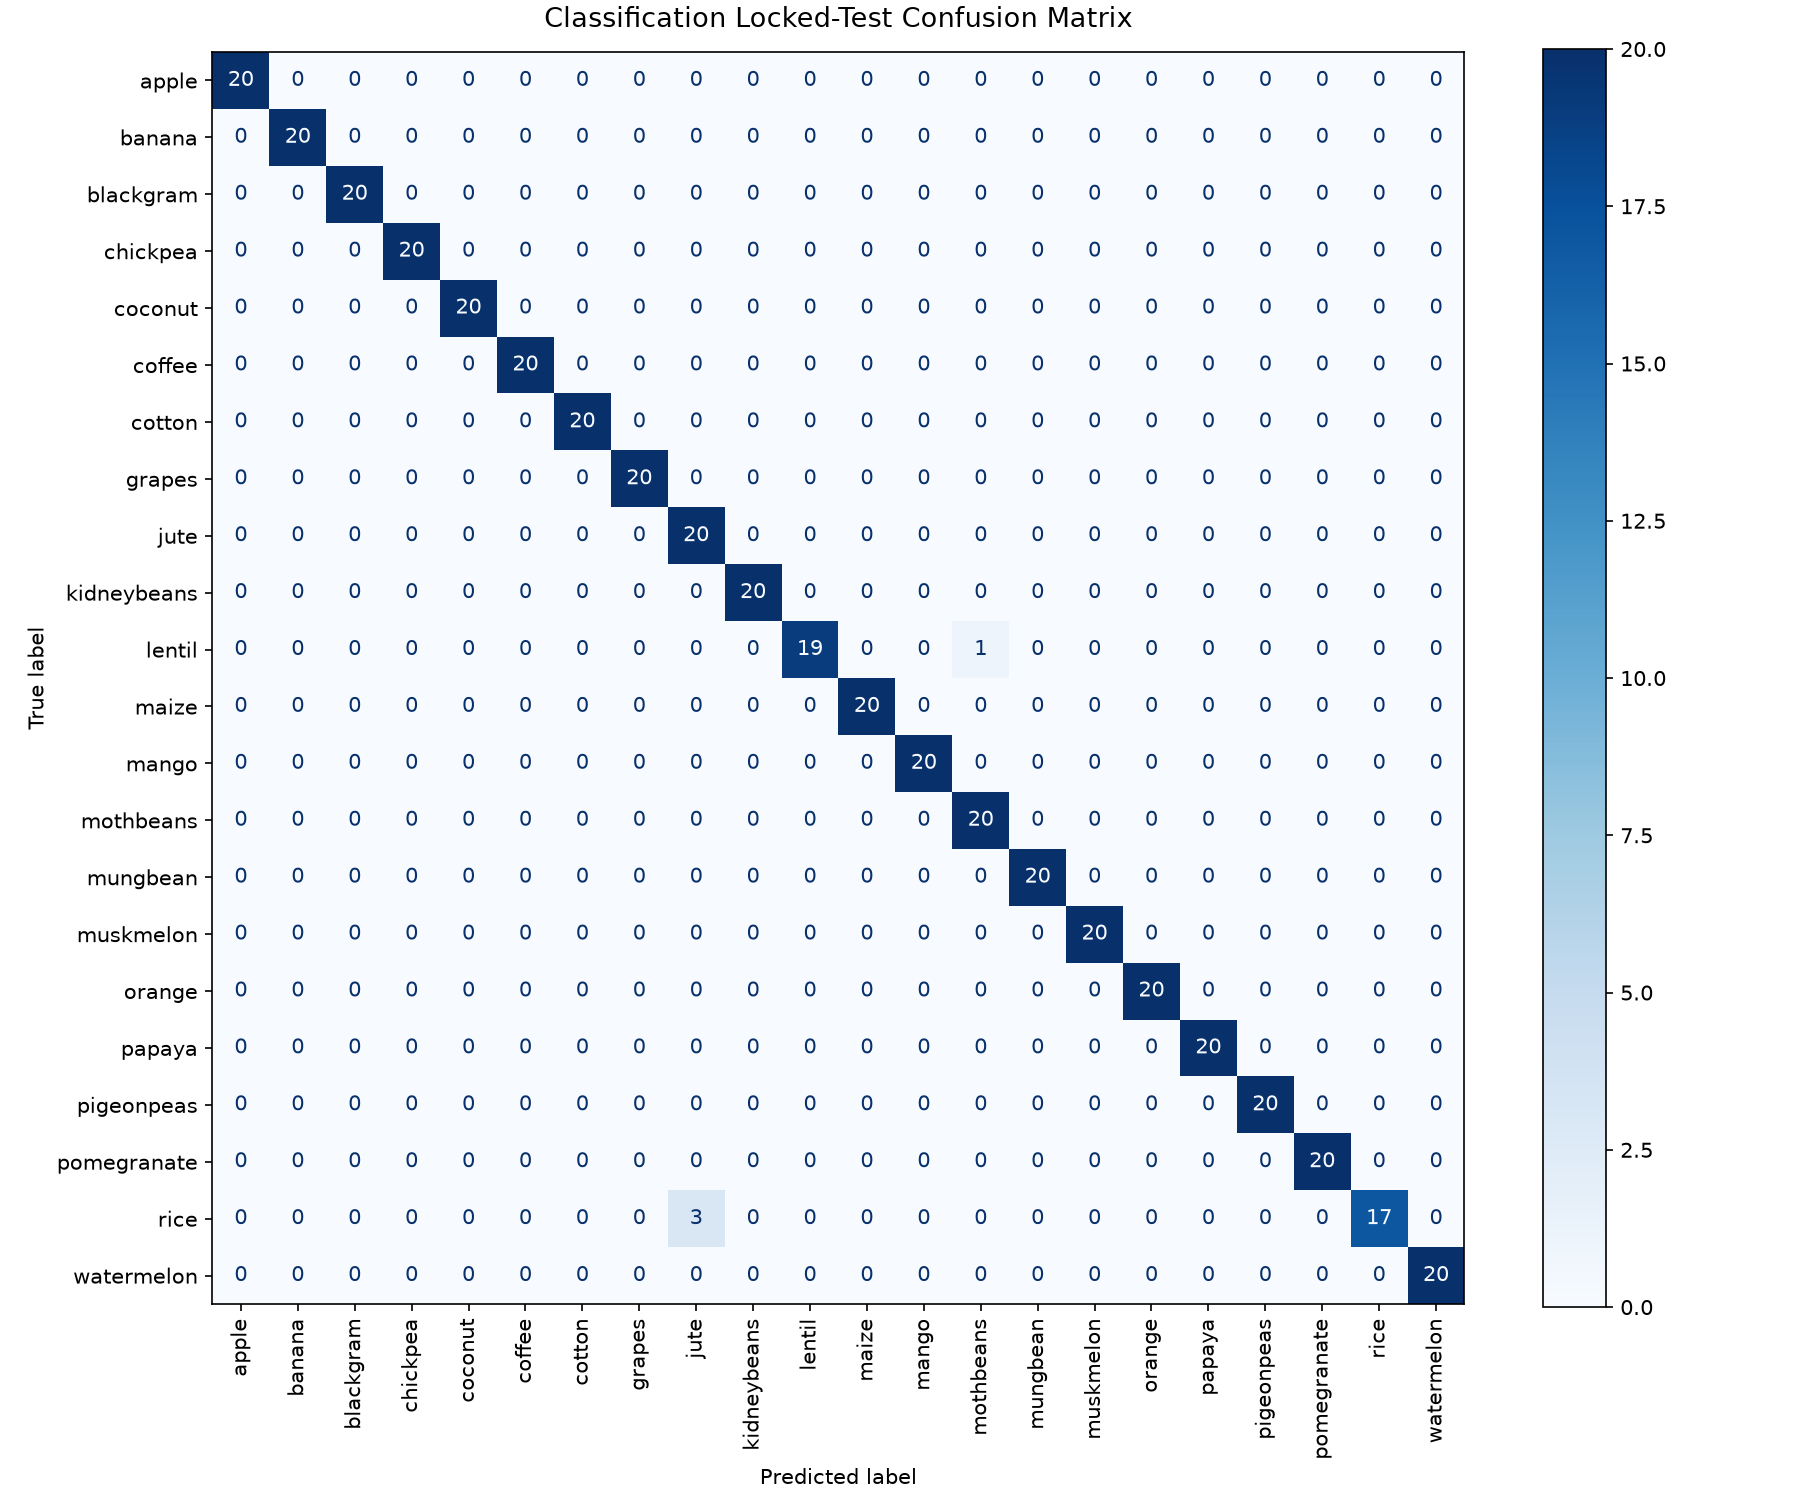

In [17]:
from src.evaluation import plot_confusion_matrix_display
from src.config import FIGURES_CLS_DIR

classes = sorted(df_cls[CLS_TARGET].unique().tolist())
FIGURES_CLS_DIR.mkdir(parents=True, exist_ok=True)
cm_path = FIGURES_CLS_DIR / 'confusion_matrix.png'
plot_confusion_matrix_display(test_cls[CLS_TARGET].to_numpy(), test_pred_final, classes, cm_path)

from IPython.display import Image, display
display(Image(filename=str(cm_path), width=750))


**Figure 2. Classification Confusion Matrix (Locked Test Set):**  
The confusion matrix displays strong concentration along the main diagonal, confirming clean separation among the 22 crop classes. Off-diagonal errors are concentrated in a small number of class pairs. These confusion patterns describe benchmark-label prediction and should not be interpreted as evidence of agronomic similarity.

## 17. Overfitting Diagnostics
Comparing training, validation, and test metrics to assess generalization gaps.

In [18]:
rows = []
for m_label, pipe in [('forest', fitted_candidates[selected_candidate]), ('forest_tuned', tuned_pipe)]:
    tr_m = evaluate_classification(train_cls[CLS_TARGET], pipe.predict(train_cls[CLS_FEATURES]))
    va_m = evaluate_classification(val_cls[CLS_TARGET], pipe.predict(val_cls[CLS_FEATURES]))
    te_m = evaluate_classification(test_cls[CLS_TARGET], pipe.predict(test_cls[CLS_FEATURES]))
    rows.append({
        'model': m_label,
        'train_macro_F1': round(tr_m['macro_F1'], 4),
        'val_macro_F1': round(va_m['macro_F1'], 4),
        'test_macro_F1': round(te_m['macro_F1'], 4),
        'train_accuracy': round(tr_m['accuracy'], 4),
        'val_accuracy': round(va_m['accuracy'], 4),
        'test_accuracy': round(te_m['accuracy'], 4),
        'train_to_val_gap': round(va_m['macro_F1'] - tr_m['macro_F1'], 4),
        'val_to_test_gap': round(te_m['macro_F1'] - va_m['macro_F1'], 4),
    })
overfit_df = pd.DataFrame(rows)
display(overfit_df)

sel_overfit = overfit_df[overfit_df['model'] == final_cls_name].iloc[0]
va_m = {'macro_F1': sel_overfit['val_macro_F1']}
te_m = {'macro_F1': sel_overfit['test_macro_F1'], 'accuracy': sel_overfit['test_accuracy']}


,model,train_macro_F1,val_macro_F1,test_macro_F1,train_accuracy,val_accuracy,test_accuracy,train_to_val_gap,val_to_test_gap
0,forest,0.9992,0.9932,0.9909,0.9992,0.9932,0.9909,-0.0060,-0.0023
1,forest_tuned,0.9962,0.9863,0.9931,0.9962,0.9864,0.9932,-0.0099,0.0068


## 18. Model Bundle Creation and Reload Identity Verification
Packaging the trained classification pipeline with preprocessing and verifying exact prediction identity upon reload.

In [19]:
import joblib
import numpy as np
from src.inference import create_model_bundle
from src.config import MODELS_CLS_DIR

cls_bundle_path = MODELS_CLS_DIR / 'selected_bundle.joblib'
if cls_bundle_path.exists():
    cls_bundle = joblib.load(cls_bundle_path)
else:
    cls_bundle = create_model_bundle(
        pipeline=final_cls_pipe,
        task='classification',
        training_df=train_cls,
        data_sha256=data_sha,
        config_sha256=cfg_sha,
        model_name=final_cls_name,
        save_path=cls_bundle_path,
    )

reloaded_bundle = joblib.load(cls_bundle_path)
sample_d3 = test_cls.head(5)
pred_orig = cls_bundle['pipeline'].predict(sample_d3[CLS_FEATURES])
pred_reload = reloaded_bundle['pipeline'].predict(sample_d3[CLS_FEATURES])
assert np.array_equal(pred_orig, pred_reload), 'Prediction mismatch upon reload!'
print('Reload Identity Check: PASSED. Deserialized predictions are identical.')
print('Sample Predictions:', list(pred_orig))


Reload Identity Check: PASSED. Deserialized predictions are identical.
Sample Predictions: ['rice', 'rice', 'rice', 'jute', 'rice']


## 19. Validated Inference and Out-of-Bounds Rejection
Demonstrating verified inference with input validation against physical bounds.

In [20]:
from src.inference import predict_validated

# 1. Valid Input Record
valid_record = [{
    'N': 90, 'P': 42, 'K': 43,
    'temperature': 20.87, 'humidity': 82.0,
    'ph': 6.5, 'rainfall': 202.93
}]
val_pred = predict_validated(cls_bundle, valid_record)
print(f'Valid Input Predicted Crop: {val_pred[0]}')

# 2. Physical Bound Rejection (Invalid pH > 14)
try:
    predict_validated(cls_bundle, [{'N': 90, 'P': 42, 'K': 43, 'temperature': 25, 'humidity': 80, 'ph': 16.5, 'rainfall': 100}])
except ValueError as exc:
    print(f'Expected Safeguard Rejection (Invalid pH): {exc}')


Valid Input Predicted Crop: rice
Expected Safeguard Rejection (Invalid pH): Soil pH must be between 0 and 14


## 20. Conclusion and Agronomic Limitations
Synthesizing empirical classification results from the current executed run following the course guidelines.

In [21]:
conclusion = (
    f'For multi-class crop label classification across 22 categories, {final_cls_name} achieved '
    f'a validation macro F1 of {va_m["macro_F1"]:.4f} and a locked-test macro F1 of {te_m["macro_F1"]:.4f} '
    f'(accuracy: {te_m["accuracy"]:.4f}), outperforming the majority baseline '
    f'(locked-test macro F1: {test_metrics_maj["macro_F1"]:.4f}). '
    f'Results confirm distinct cluster separation among crop categories in the curated benchmark dataset '
    f'but do not establish agronomically valid or operational farm-level crop recommendation guidance.'
)
print('EXPERIMENT 08 CLASSIFICATION AUDIT CONCLUSION:')
print(conclusion)
print('\nAgronomic Limitations:')
print('1. High classification metrics reflect clean synthetic clustering in curated benchmark data.')
print('2. Real-world agronomic recommendations require multi-depth soil chemistry, water availability, market prices, and pest epidemiology.')


EXPERIMENT 08 CLASSIFICATION AUDIT CONCLUSION:
For multi-class crop label classification across 22 categories, forest achieved a validation macro F1 of 0.9932 and a locked-test macro F1 of 0.9909 (accuracy: 0.9909), outperforming the majority baseline (locked-test macro F1: 0.0040). Results confirm distinct cluster separation among crop categories in the curated benchmark dataset but do not establish agronomically valid or operational farm-level crop recommendation guidance.

Agronomic Limitations:
1. High classification metrics reflect clean synthetic clustering in curated benchmark data.
2. Real-world agronomic recommendations require multi-depth soil chemistry, water availability, market prices, and pest epidemiology.
